# M3.T2 — Tree-Based Model: XGBoost
**Task:** Train XGBoost model for Probability of Default prediction  
**Baseline (Logistic Regression):** ROC-AUC = 0.7149 | Class-1 F1 = 0.41 | Accuracy = 0.75  
**Preprocessing:** Same pipeline as LR notebook (imputation → OHE → scaling)

In [1]:
%pip install xgboost scikit-learn pandas numpy matplotlib --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded!')

Libraries loaded!


## 1. Load Data

In [3]:
file_id = "1egYkWM65LIn8Q2rVqVBTa-XjNqaJk2J_"
url = f"https://drive.usercontent.google.com/download?id={file_id}&export=download&confirm=t"

loan_df = pd.read_csv(url)
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2255820 entries, 0 to 2255819
Data columns (total 51 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   int64  
 1   funded_amnt                 int64  
 2   term                        int64  
 3   int_rate                    float64
 4   sub_grade                   object 
 5   emp_title                   object 
 6   emp_length                  float64
 7   home_ownership              object 
 8   annual_inc                  float64
 9   verification_status         object 
 10  loan_status                 object 
 11  purpose                     object 
 12  addr_state                  object 
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  earliest_cr_line            object 
 16  inq_last_6mths              float64
 17  open_acc                    float64
 18  pub_rec                     float64
 19  revol_bal            

## 2. Same Preprocessing as LR Notebook

In [4]:
# Drop same high-cardinality / redundant columns as LR notebook
loan_df = loan_df.drop(columns=['emp_title', 'addr_state', 'earliest_cr_line', 'funded_amnt'])

# Binary target — same mapping as LR
loan_df = loan_df[loan_df['loan_status'].isin([
    'Fully Paid', 'Charged Off', 'Default',
    'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
])]

loan_df['loan_status'] = loan_df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
})

print(f"Shape after filtering: {loan_df.shape}")
print(f"Class distribution:\n{loan_df['loan_status'].value_counts()}")
print(f"Default rate: {loan_df['loan_status'].mean():.2%}")

Shape after filtering: (1303886, 47)
Class distribution:
loan_status
0    1042005
1     261881
Name: count, dtype: int64
Default rate: 20.08%


## 3. Train/Test Split (same as LR: 70/30, stratified)

In [5]:
X = loan_df.drop(columns='loan_status')
y = loan_df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.2%}")
print(f"Test default rate:  {y_test.mean():.2%}")

Train: 912,720 | Test: 391,166
Train default rate: 20.08%
Test default rate:  20.08%


## 4. Imputation (same as LR: median for numeric, mode for categorical)

In [6]:
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns

# Fit on train only — avoid leakage
median_values = X_train[num_cols].median()
X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)

for col in cat_cols:
    mode_value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

print("Missing in X_train:", X_train.isnull().sum().sum())
print("Missing in X_test: ", X_test.isnull().sum().sum())

Missing in X_train: 0
Missing in X_test:  0


## 5. Encoding & Scaling (same as LR)

In [7]:
# One-Hot Encoding
encoder = OneHotEncoder(drop='first', sparse_output=True)
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

# Scaling
scaler = StandardScaler(with_mean=False)
X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols])

X_train_num_sparse = sparse.csr_matrix(X_train_num_scaled)
X_test_num_sparse = sparse.csr_matrix(X_test_num_scaled)

# Combine
X_train_final = sparse.hstack([X_train_num_sparse, X_train_cat])
X_test_final = sparse.hstack([X_test_num_sparse, X_test_cat])

print(f"Final train shape: {X_train_final.shape}")
print(f"Final test shape:  {X_test_final.shape}")

Final train shape: (912720, 96)
Final test shape:  (391166, 96)


## 6. Train XGBoost

**Key hyperparameters:**
- `scale_pos_weight` — class imbalance handle karta hai (neg/pos ratio)
- `max_depth=6` — tree depth, overfitting control
- `learning_rate=0.1` — step size
- `n_estimators=300` — number of trees
- `subsample=0.8` — row sampling per tree
- `colsample_bytree=0.8` — feature sampling per tree

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Class imbalance ratio
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos
print(f"scale_pos_weight = {scale_pos:.2f}")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

# Perform 5-fold stratified cross-validation on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


xgb_model.fit(
    X_train_final, y_train,
    eval_set=[(X_test_final, y_test)],
    verbose=50
)

print("\nTraining complete!")

scale_pos_weight = 3.98
[0]	validation_0-auc:0.66975
[50]	validation_0-auc:0.72392
[100]	validation_0-auc:0.72795
[150]	validation_0-auc:0.72991
[200]	validation_0-auc:0.73112
[250]	validation_0-auc:0.73201
[299]	validation_0-auc:0.73244

Training complete!


## 7. Evaluate — M3.T4 (ROC-AUC, Precision-Recall, F1, Confusion Matrix)

In [9]:
y_pred = xgb_model.predict(X_test_final)
y_prob = xgb_model.predict_proba(X_test_final)[:, 1]

auc = roc_auc_score(y_test, y_prob)

# CV F1-score
f1_scores = cross_val_score(
    xgb_model,
    X_train_final,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

# CV ROC-AUC
roc_auc_scores = cross_val_score(
    xgb_model,
    X_train_final,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("XGBoost Mean CV F1:", f1_scores.mean())
print("XGBoost Mean CV ROC AUC:", roc_auc_scores.mean())


print("=" * 55)
print("XGBoost Results")
print("=" * 55)
print(classification_report(y_test, y_pred))
print(f"ROC AUC: {auc:.4f}")
print("\n--- vs Baseline (Logistic Regression) ---")
print(f"LR  ROC-AUC : 0.7149  →  XGB ROC-AUC : {auc:.4f}")
print(f"LR  Class-1 F1: 0.41  →  XGB Class-1 F1: (see above)")
print(f"LR  Accuracy: 0.75    →  XGB Accuracy: (see above)")

XGBoost Mean CV F1: 0.44511881078938875
XGBoost Mean CV ROC AUC: 0.7296315387023059
XGBoost Results
              precision    recall  f1-score   support

           0       0.89      0.66      0.76    312602
           1       0.33      0.68      0.45     78564

    accuracy                           0.66    391166
   macro avg       0.61      0.67      0.60    391166
weighted avg       0.78      0.66      0.70    391166

ROC AUC: 0.7324

--- vs Baseline (Logistic Regression) ---
LR  ROC-AUC : 0.7149  →  XGB ROC-AUC : 0.7324
LR  Class-1 F1: 0.41  →  XGB Class-1 F1: (see above)
LR  Accuracy: 0.75    →  XGB Accuracy: (see above)


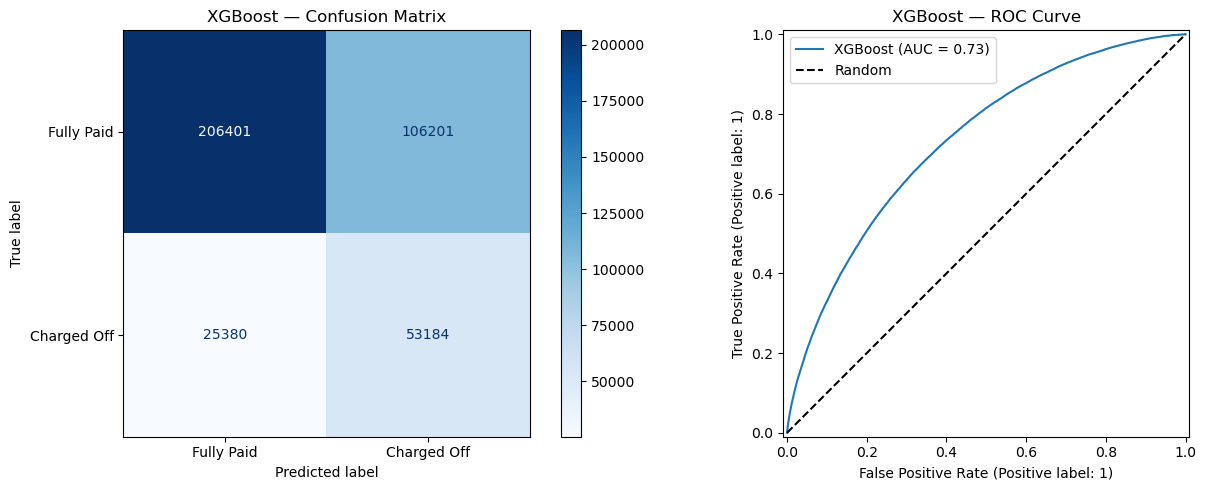

In [10]:
# Confusion Matrix + ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fully Paid', 'Charged Off'])
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='XGBoost')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_title('XGBoost — ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('xgb_evaluation.png', dpi=150)
plt.show()

## 8. Feature Importance

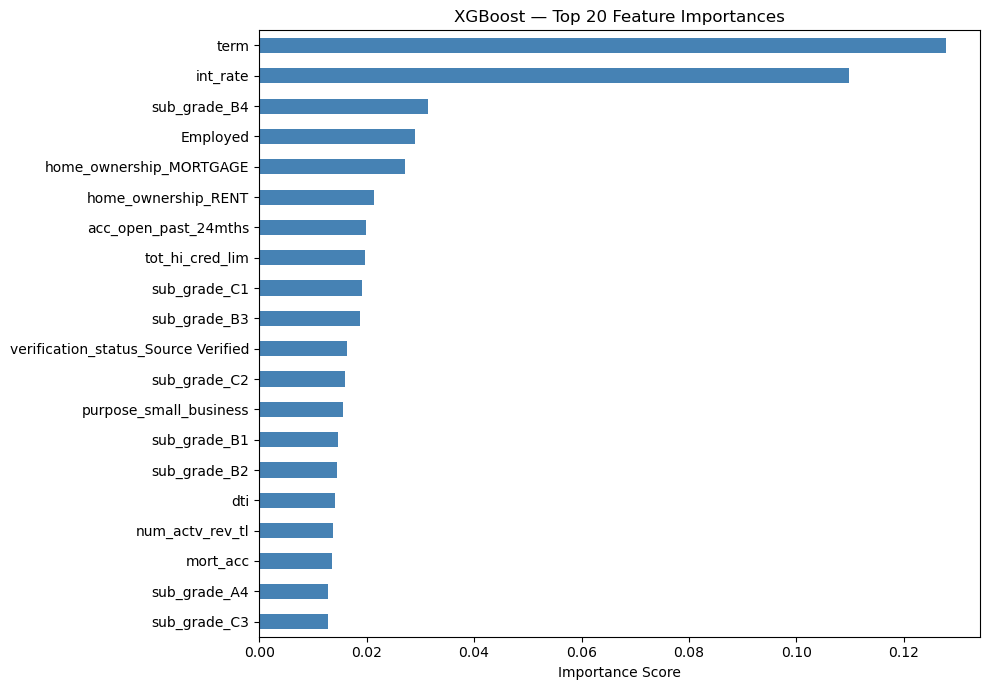


Top 10 features:
term                       0.127789
int_rate                   0.109838
sub_grade_B4               0.031427
Employed                   0.028921
home_ownership_MORTGAGE    0.027217
home_ownership_RENT        0.021351
acc_open_past_24mths       0.019813
tot_hi_cred_lim            0.019622
sub_grade_C1               0.019141
sub_grade_B3               0.018716
dtype: float32


In [11]:
# Reconstruct feature names after OHE
ohe_feature_names = encoder.get_feature_names_out(cat_cols)
all_feature_names = list(num_cols) + list(ohe_feature_names)

feat_imp = pd.Series(xgb_model.feature_importances_, index=all_feature_names)
top20 = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('XGBoost — Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features:")
print(top20.head(10))

## 9. Save Model

In [12]:
'''joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(encoder, 'xgb_encoder.pkl')
joblib.dump(scaler, 'xgb_scaler.pkl')
print("Model, encoder, scaler saved!")
'''

'joblib.dump(xgb_model, \'xgb_model.pkl\')\njoblib.dump(encoder, \'xgb_encoder.pkl\')\njoblib.dump(scaler, \'xgb_scaler.pkl\')\nprint("Model, encoder, scaler saved!")\n'

# Probability Calibration

In [13]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

# Platt Scaling (Sigmoid)
calibrated_sigmoid = CalibratedClassifierCV(
    xgb_model,  # your trained logistic model OR xgb_model
    method='sigmoid',
    cv=3
)

calibrated_sigmoid.fit(X_train_final, y_train)

# Isotonic Regression
calibrated_isotonic = CalibratedClassifierCV(
    xgb_model,
    method='isotonic',
    cv=3
)

calibrated_isotonic.fit(X_train_final, y_train)

# Original
y_prob_orig = xgb_model.predict_proba(X_test_final)[:,1]

# Sigmoid calibrated
y_prob_sig = calibrated_sigmoid.predict_proba(X_test_final)[:,1]

# Isotonic calibrated
y_prob_iso = calibrated_isotonic.predict_proba(X_test_final)[:,1]

##### Calibration Curve

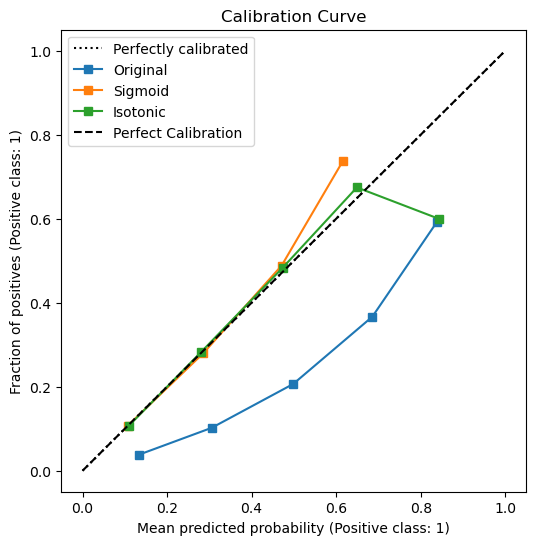

In [14]:
fig, ax = plt.subplots(figsize=(6,6))

CalibrationDisplay.from_predictions(y_test, y_prob_orig, name='Original', ax=ax)
CalibrationDisplay.from_predictions(y_test, y_prob_sig, name='Sigmoid', ax=ax)
CalibrationDisplay.from_predictions(y_test, y_prob_iso, name='Isotonic', ax=ax)

ax.plot([0,1], [0,1], 'k--', label='Perfect Calibration')
ax.set_title("Calibration Curve")
ax.legend()

plt.show()

In [15]:
y_pred_sig = (y_prob_sig >= 0.5).astype(int)

print(classification_report(y_test, y_pred_sig))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    312602
           1       0.60      0.09      0.16     78564

    accuracy                           0.81    391166
   macro avg       0.70      0.54      0.52    391166
weighted avg       0.77      0.81      0.74    391166



In [16]:
y_pred_iso = (y_prob_iso >= 0.5).astype(int)
print(classification_report(y_test, y_pred_iso))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    312602
           1       0.59      0.10      0.17     78564

    accuracy                           0.81    391166
   macro avg       0.70      0.54      0.53    391166
weighted avg       0.77      0.81      0.74    391166



In [17]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 50)
f1_scores_sig = []
f1_scores_iso = []

for t in thresholds:
    y_pred_sig = (y_prob_sig >= t).astype(int)
    y_pred_iso = (y_prob_iso >= t).astype(int)
    f1_scores_sig.append(f1_score(y_test, y_pred_sig))
    f1_scores_iso.append(f1_score(y_test, y_pred_iso))

best_threshold_sig = thresholds[np.argmax(f1_scores_sig)]
best_threshold_iso = thresholds[np.argmax(f1_scores_iso)]
best_f1_sig = max(f1_scores_sig)
best_f1_iso = max(f1_scores_iso)

print("Best threshold-sigmoid:", best_threshold_sig)
print("Best F1-score-sigmoid:", best_f1_sig)
print("Best threshold-isotonic:", best_threshold_iso)
print("Best F1-score-isotonic:", best_f1_iso)

Best threshold-sigmoid: 0.2306122448979592
Best F1-score-sigmoid: 0.4499041661058953
Best threshold-isotonic: 0.2306122448979592
Best F1-score-isotonic: 0.45014661374114895


In [18]:
X_test_with_prob = X_test.copy()
X_test_with_prob['predicted_prob'] = y_prob_iso

In [19]:
X_test_with_prob.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391166 entries, 941348 to 1512882
Data columns (total 47 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   391166 non-null  int64  
 1   term                        391166 non-null  int64  
 2   int_rate                    391166 non-null  float64
 3   sub_grade                   391166 non-null  object 
 4   emp_length                  391166 non-null  float64
 5   home_ownership              391166 non-null  object 
 6   annual_inc                  391166 non-null  float64
 7   verification_status         391166 non-null  object 
 8   purpose                     391166 non-null  object 
 9   dti                         391166 non-null  float64
 10  delinq_2yrs                 391166 non-null  float64
 11  inq_last_6mths              391166 non-null  float64
 12  open_acc                    391166 non-null  float64
 13  pub_rec      

In [ ]:
# X_test_with_prob.to_csv("test_predictions.csv", index=False)

# csv file link
# https://drive.google.com/file/d/1ufiIVuDW7U3XJgdOlrBuppSg71gvHMs1/view?usp=sharing